## 1. Imports and configuration

In [1]:
from pathlib import Path
import os
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

SEED = 42

# First test: set True. Final leaderboard run: set False.
FAST_MODE = False

N_FOLDS = 3 if FAST_MODE else 5
WEIGHT_STEP = 0.20 if FAST_MODE else 0.10

# Model parameters selected from subject-aware training validation.
LDA_SHRINKAGE = 0.003
SVM_C = 3.0
SVM_GAMMA = "scale"

# Small, bounded post-processing searches use only OOF training predictions.
USE_SIT_STAND_SPECIALIST = True
USE_CLASS_FACTOR_CALIBRATION = True

# Blend full-data and cross-validation-bagged test probabilities.
# The notebook also saves the full-only and CV-bagged alternatives.
FULL_MODEL_WEIGHT = 0.50
CV_BAG_WEIGHT = 1.0 - FULL_MODEL_WEIGHT

if Path("/kaggle/input").exists():
    INPUT_ROOT = Path("/kaggle/input")
    OUTPUT_DIR = Path("/kaggle/working/submission5_subject_ensemble_outputs")
else:
    # Local fallback used only to verify this notebook outside Kaggle.
    INPUT_ROOT = Path(os.environ.get("HAR_INPUT_ROOT", "/mnt/data/har_work"))
    OUTPUT_DIR = Path("/mnt/data/submission5_subject_ensemble_outputs")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("FAST_MODE:", FAST_MODE)
print("Number of folds:", N_FOLDS)
print("Input root:", INPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


FAST_MODE: False
Number of folds: 5
Input root: /kaggle/input
Output directory: /kaggle/working/submission5_subject_ensemble_outputs


## 2. Locate the competition CSV files

In [2]:
csv_files = list(INPUT_ROOT.rglob("*.csv"))

print("CSV files found:")
for path in csv_files:
    print(" ", path)


def choose_csv(file_name, expected_rows=None):
    candidates = [
        path for path in csv_files
        if path.name.lower() == file_name.lower()
    ]

    if not candidates:
        return None, None

    scored = []

    for path in candidates:
        try:
            frame = pd.read_csv(path)
            row_difference = (
                abs(len(frame) - expected_rows)
                if expected_rows is not None
                else 0
            )
            scored.append((row_difference, -frame.shape[1], path, frame))
        except Exception:
            continue

    if not scored:
        return None, None

    scored.sort(key=lambda item: (item[0], item[1]))
    _, _, selected_path, selected_frame = scored[0]
    return selected_path, selected_frame


TRAIN_PATH, train_df = choose_csv("train.csv", expected_rows=7352)
TEST_PATH, test_df = choose_csv("test.csv", expected_rows=2947)
SAMPLE_PATH, sample_submission_df = choose_csv(
    "sample_submission.csv",
    expected_rows=2947,
)

if sample_submission_df is None:
    SAMPLE_PATH, sample_submission_df = choose_csv(
        "submission.csv",
        expected_rows=2947,
    )

if train_df is None or test_df is None:
    raise FileNotFoundError(
        "Could not locate competition train.csv and test.csv. "
        "Attach the CO5420 Human Activity Recognition competition input."
    )

print("\nSelected train:", TRAIN_PATH)
print("Selected test:", TEST_PATH)
print("Selected sample submission:", SAMPLE_PATH)
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

if sample_submission_df is not None:
    print("Sample submission shape:", sample_submission_df.shape)
    display(sample_submission_df.head())


CSV files found:
  /kaggle/input/competitions/co5420-human-activity-recognition/sample_submission.csv
  /kaggle/input/competitions/co5420-human-activity-recognition/train.csv
  /kaggle/input/competitions/co5420-human-activity-recognition/co5420-human-activity-recognition/sample_submission.csv
  /kaggle/input/competitions/co5420-human-activity-recognition/co5420-human-activity-recognition/train.csv
  /kaggle/input/competitions/co5420-human-activity-recognition/co5420-human-activity-recognition/test.csv

Selected train: /kaggle/input/competitions/co5420-human-activity-recognition/train.csv
Selected test: /kaggle/input/competitions/co5420-human-activity-recognition/co5420-human-activity-recognition/test.csv
Selected sample submission: /kaggle/input/competitions/co5420-human-activity-recognition/sample_submission.csv
Train shape: (7352, 563)
Test shape: (2947, 563)


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


,id,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject
0,1,0.257178,-0.023285,-0.014654,-0.938404,-0.920091,-0.667683,-0.952501,-0.925249,-0.674302,...,-0.330370,-0.705974,0.006462,0.162920,-0.825886,0.271151,-0.720009,0.276801,-0.057978,2
1,2,0.286027,-0.013163,-0.119083,-0.975415,-0.967458,-0.944958,-0.986799,-0.968401,-0.945823,...,-0.121845,-0.594944,-0.083495,0.017500,-0.434375,0.920593,-0.698091,0.281343,-0.083898,2
2,3,0.275485,-0.026050,-0.118152,-0.993819,-0.969926,-0.962748,-0.994403,-0.970735,-0.963483,...,-0.190422,-0.640736,-0.034956,0.202302,0.064103,0.145068,-0.702771,0.280083,-0.079346,2
3,4,0.270298,-0.032614,-0.117520,-0.994743,-0.973268,-0.967091,-0.995274,-0.974471,-0.968897,...,-0.344418,-0.736124,-0.017067,0.154438,0.340134,0.296407,-0.698954,0.284114,-0.077108,2
4,5,0.274833,-0.027848,-0.129527,-0.993852,-0.967445,-0.978295,-0.994111,-0.965953,-0.977346,...,-0.534685,-0.846595,-0.002223,-0.040046,0.736715,-0.118545,-0.692245,0.290722,-0.073857,2


Sample submission shape: (2947, 2)


,id,Activity
0,1,LAYING
1,2,LAYING
2,3,LAYING
3,4,LAYING
4,5,LAYING


## 3. Identify columns and construct feature matrices

In [3]:
def find_column_case_insensitive(columns, possible_names):
    lookup = {column.lower(): column for column in columns}

    for name in possible_names:
        if name.lower() in lookup:
            return lookup[name.lower()]

    return None


TARGET_COLUMN = find_column_case_insensitive(
    train_df.columns,
    ["Activity", "target", "label", "class"],
)

SUBJECT_COLUMN = find_column_case_insensitive(
    train_df.columns,
    ["subject", "subject_id", "person", "user"],
)

TRAIN_ID_COLUMN = find_column_case_insensitive(
    train_df.columns,
    ["id", "index", "sample_id"],
)

TEST_ID_COLUMN = find_column_case_insensitive(
    test_df.columns,
    ["id", "index", "sample_id"],
)

if TARGET_COLUMN is None:
    raise ValueError("Could not identify the activity target column.")

if SUBJECT_COLUMN is None:
    raise ValueError(
        "This method requires a subject column for subject-aware "
        "normalization and GroupKFold validation."
    )

excluded_columns = {TARGET_COLUMN, SUBJECT_COLUMN}
if TRAIN_ID_COLUMN is not None:
    excluded_columns.add(TRAIN_ID_COLUMN)

feature_columns = [
    column for column in train_df.columns
    if column not in excluded_columns
    and column in test_df.columns
]

numeric_feature_columns = []
for column in feature_columns:
    train_numeric = pd.to_numeric(train_df[column], errors="coerce")
    test_numeric = pd.to_numeric(test_df[column], errors="coerce")

    if not train_numeric.isna().all() and not test_numeric.isna().all():
        numeric_feature_columns.append(column)

feature_columns = numeric_feature_columns

X_raw = (
    train_df[feature_columns]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=np.float64)
)

X_test_raw = (
    test_df[feature_columns]
    .apply(pd.to_numeric, errors="coerce")
    .to_numpy(dtype=np.float64)
)

if np.isnan(X_raw).any() or np.isnan(X_test_raw).any():
    raise ValueError("NaN values were found in the feature matrices.")

train_subjects = train_df[SUBJECT_COLUMN].to_numpy()
test_subjects = test_df[SUBJECT_COLUMN].to_numpy()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train_df[TARGET_COLUMN].astype(str))

CLASS_NAMES = label_encoder.classes_
NUMBER_OF_CLASSES = len(CLASS_NAMES)
CLASS_TO_ID = {name: index for index, name in enumerate(CLASS_NAMES)}

required_classes = {
    "LAYING",
    "SITTING",
    "STANDING",
    "WALKING",
    "WALKING_DOWNSTAIRS",
    "WALKING_UPSTAIRS",
}

if set(CLASS_NAMES) != required_classes:
    raise ValueError(
        "Unexpected activity classes. Found: "
        f"{CLASS_NAMES.tolist()}"
    )

print("Target column:", TARGET_COLUMN)
print("Subject column:", SUBJECT_COLUMN)
print("Test ID column:", TEST_ID_COLUMN)
print("Number of engineered features:", len(feature_columns))
print("Training matrix:", X_raw.shape)
print("Test matrix:", X_test_raw.shape)
print("Classes:", CLASS_NAMES)
print("Training subjects:", np.unique(train_subjects))
print("Test subjects:", np.unique(test_subjects))

if len(feature_columns) != 561:
    print(
        "Warning: expected 561 engineered features, "
        f"but found {len(feature_columns)}."
    )


Target column: Activity
Subject column: subject
Test ID column: id
Number of engineered features: 561
Training matrix: (7352, 561)
Test matrix: (2947, 561)
Classes: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']
Training subjects: [ 1  3  5  6  7  8 11 14 15 16 17 19 21 22 23 25 26 27 28 29 30]
Test subjects: [ 2  4  9 10 12 13 18 20 24]


## 4. Build subject-normalized feature representations

In [4]:
def create_subject_representations(X, subjects, epsilon=1e-6):
    """
    Create three unlabeled, within-subject feature representations.

    centered: feature - subject feature mean
    zscore:   centered / subject feature standard deviation
    rank:     within-subject percentile rank mapped to [-1, 1]

    No activity labels are used.
    """
    centered = np.empty_like(X, dtype=np.float64)
    zscore = np.empty_like(X, dtype=np.float64)
    rank_scaled = np.empty_like(X, dtype=np.float64)

    for subject in np.unique(subjects):
        indices = np.flatnonzero(subjects == subject)
        subject_values = X[indices]

        subject_mean = subject_values.mean(axis=0)
        subject_std = subject_values.std(axis=0)
        subject_std = np.where(subject_std < epsilon, 1.0, subject_std)

        centered[indices] = subject_values - subject_mean
        zscore[indices] = centered[indices] / subject_std

        percentile_rank = (
            pd.DataFrame(subject_values)
            .rank(method="average", pct=True)
            .to_numpy(dtype=np.float64)
        )
        rank_scaled[indices] = 2.0 * percentile_rank - 1.0

    return centered, zscore, rank_scaled


X_centered, X_zscore, X_rank = create_subject_representations(
    X_raw,
    train_subjects,
)

X_test_centered, X_test_zscore, X_test_rank = (
    create_subject_representations(
        X_test_raw,
        test_subjects,
    )
)

for name, matrix in {
    "train centered": X_centered,
    "train z-score": X_zscore,
    "train rank": X_rank,
    "test centered": X_test_centered,
    "test z-score": X_test_zscore,
    "test rank": X_test_rank,
}.items():
    print(
        name,
        matrix.shape,
        "NaN:", np.isnan(matrix).any(),
        "Inf:", np.isinf(matrix).any(),
    )


train centered (7352, 561) NaN: False Inf: False
train z-score (7352, 561) NaN: False Inf: False
train rank (7352, 561) NaN: False Inf: False
test centered (2947, 561) NaN: False Inf: False
test z-score (2947, 561) NaN: False Inf: False
test rank (2947, 561) NaN: False Inf: False


## 5. Define activity groups and cross-validation

In [5]:
STATIC_CLASS_IDS = np.array([
    CLASS_TO_ID["LAYING"],
    CLASS_TO_ID["SITTING"],
    CLASS_TO_ID["STANDING"],
])

DYNAMIC_CLASS_IDS = np.array([
    CLASS_TO_ID["WALKING"],
    CLASS_TO_ID["WALKING_DOWNSTAIRS"],
    CLASS_TO_ID["WALKING_UPSTAIRS"],
])

SITTING_ID = CLASS_TO_ID["SITTING"]
STANDING_ID = CLASS_TO_ID["STANDING"]

# 0 = static, 1 = dynamic
y_group = np.isin(y, DYNAMIC_CLASS_IDS).astype(np.int64)

cross_validator = GroupKFold(n_splits=N_FOLDS)
folds = list(
    cross_validator.split(
        X_raw,
        y,
        groups=train_subjects,
    )
)

print("Number of folds:", len(folds))

for fold_number, (training_indices, validation_indices) in enumerate(
    folds,
    start=1,
):
    training_fold_subjects = np.unique(train_subjects[training_indices])
    validation_fold_subjects = np.unique(train_subjects[validation_indices])
    overlap = np.intersect1d(
        training_fold_subjects,
        validation_fold_subjects,
    )

    print(
        f"Fold {fold_number}: train rows={len(training_indices)}, "
        f"validation rows={len(validation_indices)}, "
        f"subject overlap={len(overlap)}"
    )

    assert len(overlap) == 0


Number of folds: 5
Fold 1: train rows=5932, validation rows=1420, subject overlap=0
Fold 2: train rows=5932, validation rows=1420, subject overlap=0
Fold 3: train rows=5935, validation rows=1417, subject overlap=0
Fold 4: train rows=5942, validation rows=1410, subject overlap=0
Fold 5: train rows=5667, validation rows=1685, subject overlap=0


## 6. Model helper functions

In [6]:
def make_lda(shrinkage=LDA_SHRINKAGE):
    return LinearDiscriminantAnalysis(
        solver="lsqr",
        shrinkage=shrinkage,
    )


def make_svm(random_state=SEED):
    return SVC(
        kernel="rbf",
        C=SVM_C,
        gamma=SVM_GAMMA,
        probability=True,
        cache_size=4000,
        random_state=random_state,
    )


def align_probabilities(probabilities, model_classes, number_of_classes):
    aligned = np.zeros(
        (len(probabilities), number_of_classes),
        dtype=np.float64,
    )

    for source_column, class_id in enumerate(model_classes):
        aligned[:, int(class_id)] = probabilities[:, source_column]

    return aligned


def calculate_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "macro_recall": recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "weighted_f1": f1_score(
            y_true,
            y_pred,
            average="weighted",
            zero_division=0,
        ),
    }


def predict_hierarchical_probabilities(
    group_model,
    dynamic_model,
    static_model,
    X_group,
    X_dynamic,
    X_static,
):
    group_probability = align_probabilities(
        group_model.predict_proba(X_group),
        group_model.classes_,
        2,
    )

    dynamic_probability = dynamic_model.predict_proba(X_dynamic)
    static_probability = static_model.predict_proba(X_static)

    result = np.zeros(
        (len(X_group), NUMBER_OF_CLASSES),
        dtype=np.float64,
    )

    for column, class_id in enumerate(dynamic_model.classes_):
        result[:, int(class_id)] = (
            group_probability[:, 1]
            * dynamic_probability[:, column]
        )

    for column, class_id in enumerate(static_model.classes_):
        result[:, int(class_id)] = (
            group_probability[:, 0]
            * static_probability[:, column]
        )

    return result


def align_sit_stand_probabilities(probabilities, model_classes):
    aligned = np.zeros((len(probabilities), 2), dtype=np.float64)

    for source_column, class_id in enumerate(model_classes):
        if int(class_id) == SITTING_ID:
            aligned[:, 0] = probabilities[:, source_column]
        elif int(class_id) == STANDING_ID:
            aligned[:, 1] = probabilities[:, source_column]

    return aligned


def apply_sit_stand_specialist(
    base_probabilities,
    specialist_probabilities,
    alpha,
):
    adjusted = base_probabilities.copy()

    pair_mass = (
        adjusted[:, SITTING_ID]
        + adjusted[:, STANDING_ID]
    )

    current_conditional = np.column_stack([
        adjusted[:, SITTING_ID],
        adjusted[:, STANDING_ID],
    ]) / (pair_mass[:, None] + 1e-12)

    blended_conditional = (
        (1.0 - alpha) * current_conditional
        + alpha * specialist_probabilities
    )

    adjusted[:, SITTING_ID] = (
        pair_mass * blended_conditional[:, 0]
    )
    adjusted[:, STANDING_ID] = (
        pair_mass * blended_conditional[:, 1]
    )

    return adjusted


## 7. Generate out-of-fold and fold-bagged test probabilities

In [7]:
MODEL_NAMES = [
    "centered_lda",
    "rank_lda",
    "zscore_svm",
    "hierarchical_lda",
]

oof_probabilities = {
    name: np.zeros(
        (len(X_raw), NUMBER_OF_CLASSES),
        dtype=np.float64,
    )
    for name in MODEL_NAMES
}

cv_test_probabilities = {
    name: np.zeros(
        (len(X_test_raw), NUMBER_OF_CLASSES),
        dtype=np.float64,
    )
    for name in MODEL_NAMES
}

oof_sit_stand_specialist = np.zeros(
    (len(X_raw), 2),
    dtype=np.float64,
)

cv_test_sit_stand_specialist = np.zeros(
    (len(X_test_raw), 2),
    dtype=np.float64,
)

fold_records = []
training_start = time.time()

for fold_number, (training_indices, validation_indices) in enumerate(
    folds,
    start=1,
):
    print("=" * 80)
    print(f"Fold {fold_number}/{len(folds)}")

    y_train_fold = y[training_indices]
    y_validation_fold = y[validation_indices]

    # 1. Subject-centered LDA
    centered_lda = make_lda()
    centered_lda.fit(
        X_centered[training_indices],
        y_train_fold,
    )

    centered_validation_probability = align_probabilities(
        centered_lda.predict_proba(
            X_centered[validation_indices]
        ),
        centered_lda.classes_,
        NUMBER_OF_CLASSES,
    )

    centered_test_probability = align_probabilities(
        centered_lda.predict_proba(X_test_centered),
        centered_lda.classes_,
        NUMBER_OF_CLASSES,
    )

    oof_probabilities["centered_lda"][
        validation_indices
    ] = centered_validation_probability

    cv_test_probabilities["centered_lda"] += (
        centered_test_probability / len(folds)
    )

    # 2. Subject-rank LDA
    rank_lda = make_lda()
    rank_lda.fit(
        X_rank[training_indices],
        y_train_fold,
    )

    rank_validation_probability = align_probabilities(
        rank_lda.predict_proba(X_rank[validation_indices]),
        rank_lda.classes_,
        NUMBER_OF_CLASSES,
    )

    rank_test_probability = align_probabilities(
        rank_lda.predict_proba(X_test_rank),
        rank_lda.classes_,
        NUMBER_OF_CLASSES,
    )

    oof_probabilities["rank_lda"][
        validation_indices
    ] = rank_validation_probability

    cv_test_probabilities["rank_lda"] += (
        rank_test_probability / len(folds)
    )

    # 3. Subject-z-score RBF SVM
    zscore_svm = make_svm(
        random_state=SEED + fold_number
    )
    zscore_svm.fit(
        X_zscore[training_indices],
        y_train_fold,
    )

    svm_validation_probability = align_probabilities(
        zscore_svm.predict_proba(
            X_zscore[validation_indices]
        ),
        zscore_svm.classes_,
        NUMBER_OF_CLASSES,
    )

    svm_test_probability = align_probabilities(
        zscore_svm.predict_proba(X_test_zscore),
        zscore_svm.classes_,
        NUMBER_OF_CLASSES,
    )

    oof_probabilities["zscore_svm"][
        validation_indices
    ] = svm_validation_probability

    cv_test_probabilities["zscore_svm"] += (
        svm_test_probability / len(folds)
    )

    # 4. Hierarchical LDA
    group_model = make_lda()
    group_model.fit(
        X_zscore[training_indices],
        y_group[training_indices],
    )

    dynamic_training_indices = training_indices[
        np.isin(y_train_fold, DYNAMIC_CLASS_IDS)
    ]
    static_training_indices = training_indices[
        np.isin(y_train_fold, STATIC_CLASS_IDS)
    ]

    dynamic_model = make_lda()
    dynamic_model.fit(
        X_rank[dynamic_training_indices],
        y[dynamic_training_indices],
    )

    static_model = make_lda()
    static_model.fit(
        X_zscore[static_training_indices],
        y[static_training_indices],
    )

    hierarchical_validation_probability = (
        predict_hierarchical_probabilities(
            group_model,
            dynamic_model,
            static_model,
            X_zscore[validation_indices],
            X_rank[validation_indices],
            X_zscore[validation_indices],
        )
    )

    hierarchical_test_probability = (
        predict_hierarchical_probabilities(
            group_model,
            dynamic_model,
            static_model,
            X_test_zscore,
            X_test_rank,
            X_test_zscore,
        )
    )

    oof_probabilities["hierarchical_lda"][
        validation_indices
    ] = hierarchical_validation_probability

    cv_test_probabilities["hierarchical_lda"] += (
        hierarchical_test_probability / len(folds)
    )

    # SITTING vs STANDING specialist on subject-rank features
    sit_stand_training_indices = training_indices[
        np.isin(
            y_train_fold,
            [SITTING_ID, STANDING_ID],
        )
    ]

    sit_stand_model = make_lda()
    sit_stand_model.fit(
        X_rank[sit_stand_training_indices],
        y[sit_stand_training_indices],
    )

    specialist_validation_probability = (
        align_sit_stand_probabilities(
            sit_stand_model.predict_proba(
                X_rank[validation_indices]
            ),
            sit_stand_model.classes_,
        )
    )

    specialist_test_probability = (
        align_sit_stand_probabilities(
            sit_stand_model.predict_proba(X_test_rank),
            sit_stand_model.classes_,
        )
    )

    oof_sit_stand_specialist[
        validation_indices
    ] = specialist_validation_probability

    cv_test_sit_stand_specialist += (
        specialist_test_probability / len(folds)
    )

    fold_record = {"fold": fold_number}

    for model_name in MODEL_NAMES:
        fold_predictions = np.argmax(
            oof_probabilities[model_name][validation_indices],
            axis=1,
        )

        fold_record[f"{model_name}_macro_f1"] = f1_score(
            y_validation_fold,
            fold_predictions,
            average="macro",
            zero_division=0,
        )

    fold_records.append(fold_record)
    print(fold_record)

training_seconds = time.time() - training_start
print(f"\nCross-validation completed in {training_seconds:.1f} seconds.")

fold_results_df = pd.DataFrame(fold_records)
fold_results_df.to_csv(
    OUTPUT_DIR / "fold_results.csv",
    index=False,
)

display(fold_results_df)


Fold 1/5
{'fold': 1, 'centered_lda_macro_f1': 0.9578928926111127, 'rank_lda_macro_f1': 0.9714976235142303, 'zscore_svm_macro_f1': 0.9766901352639117, 'hierarchical_lda_macro_f1': 0.981513374233769}
Fold 2/5
{'fold': 2, 'centered_lda_macro_f1': 0.9282385176130896, 'rank_lda_macro_f1': 0.9451383458420618, 'zscore_svm_macro_f1': 0.9430230038393758, 'hierarchical_lda_macro_f1': 0.9592961588613568}
Fold 3/5
{'fold': 3, 'centered_lda_macro_f1': 0.9905376443396491, 'rank_lda_macro_f1': 0.9834257740245441, 'zscore_svm_macro_f1': 0.9804715729707718, 'hierarchical_lda_macro_f1': 0.98038668076758}
Fold 4/5
{'fold': 4, 'centered_lda_macro_f1': 0.9764665586054662, 'rank_lda_macro_f1': 0.9826538226906356, 'zscore_svm_macro_f1': 0.9780036508717441, 'hierarchical_lda_macro_f1': 0.9728185317408956}
Fold 5/5
{'fold': 5, 'centered_lda_macro_f1': 0.9799288959933327, 'rank_lda_macro_f1': 0.958566175918954, 'zscore_svm_macro_f1': 0.9556983392789391, 'hierarchical_lda_macro_f1': 0.971306830071854}

Cross-val

,fold,centered_lda_macro_f1,rank_lda_macro_f1,zscore_svm_macro_f1,hierarchical_lda_macro_f1
0,1,0.957893,0.971498,0.976690,0.981513
1,2,0.928239,0.945138,0.943023,0.959296
2,3,0.990538,0.983426,0.980472,0.980387
3,4,0.976467,0.982654,0.978004,0.972819
4,5,0.979929,0.958566,0.955698,0.971307


## 8. Evaluate the four base models

In [8]:
base_model_records = []

for model_name in MODEL_NAMES:
    predictions = np.argmax(
        oof_probabilities[model_name],
        axis=1,
    )

    record = {
        "model": model_name,
        **calculate_metrics(y, predictions),
    }

    base_model_records.append(record)

base_model_results_df = pd.DataFrame(base_model_records)
base_model_results_df.to_csv(
    OUTPUT_DIR / "base_model_oof_results.csv",
    index=False,
)

display(base_model_results_df)


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,centered_lda,0.966404,0.967020,0.966486,0.966712,0.966351
1,rank_lda,0.965180,0.967532,0.967438,0.967436,0.965281
2,zscore_svm,0.965316,0.966338,0.966177,0.966233,0.965317
3,hierarchical_lda,0.971300,0.972359,0.972610,0.972468,0.971307


## 9. Select ensemble weights using OOF Macro F1

In [9]:
def search_simplex_weights(probability_dictionary, y_true, step):
    names = list(probability_dictionary.keys())
    units = int(round(1.0 / step))
    records = []

    # Four non-negative weights that sum exactly to one.
    for first in range(units + 1):
        for second in range(units - first + 1):
            for third in range(units - first - second + 1):
                fourth = units - first - second - third

                unit_weights = [first, second, third, fourth]
                weights = [value / units for value in unit_weights]

                blended = sum(
                    weight * probability_dictionary[name]
                    for weight, name in zip(weights, names)
                )

                predictions = np.argmax(blended, axis=1)

                records.append({
                    **{
                        f"weight_{name}": weight
                        for name, weight in zip(names, weights)
                    },
                    "macro_f1": f1_score(
                        y_true,
                        predictions,
                        average="macro",
                        zero_division=0,
                    ),
                    "accuracy": accuracy_score(
                        y_true,
                        predictions,
                    ),
                })

    results = (
        pd.DataFrame(records)
        .sort_values(
            ["macro_f1", "accuracy"],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )

    return results


weight_results_df = search_simplex_weights(
    oof_probabilities,
    y,
    WEIGHT_STEP,
)

weight_results_df.to_csv(
    OUTPUT_DIR / "ensemble_weight_search.csv",
    index=False,
)

display(weight_results_df.head(20))

BEST_WEIGHTS = {
    model_name: float(
        weight_results_df.loc[0, f"weight_{model_name}"]
    )
    for model_name in MODEL_NAMES
}

print("Selected weights:")
print(json.dumps(BEST_WEIGHTS, indent=2))
print(
    "OOF Macro F1 before specialist:",
    weight_results_df.loc[0, "macro_f1"],
)


,weight_centered_lda,weight_rank_lda,weight_zscore_svm,weight_hierarchical_lda,macro_f1,accuracy
0,0.3,0.1,0.2,0.4,0.979910,0.978781
1,0.2,0.2,0.3,0.3,0.979818,0.978645
2,0.3,0.1,0.3,0.3,0.979278,0.978237
3,0.2,0.3,0.0,0.5,0.979234,0.978101
4,0.4,0.1,0.0,0.5,0.979163,0.977965
5,0.2,0.2,0.2,0.4,0.979144,0.977965
6,0.3,0.2,0.2,0.3,0.979123,0.977965
7,0.3,0.3,0.2,0.2,0.979046,0.977829
8,0.3,0.2,0.0,0.5,0.979037,0.977829
9,0.3,0.2,0.1,0.4,0.979005,0.977829


Selected weights:
{
  "centered_lda": 0.3,
  "rank_lda": 0.1,
  "zscore_svm": 0.2,
  "hierarchical_lda": 0.4
}
OOF Macro F1 before specialist: 0.979910140799367


## 10. Tune the SITTING vs STANDING specialist

In [10]:
def weighted_probability_blend(probability_dictionary, weights):
    return sum(
        weights[name] * probability_dictionary[name]
        for name in weights
    )


base_ensemble_oof = weighted_probability_blend(
    oof_probabilities,
    BEST_WEIGHTS,
)

base_ensemble_score = f1_score(
    y,
    np.argmax(base_ensemble_oof, axis=1),
    average="macro",
    zero_division=0,
)

if USE_SIT_STAND_SPECIALIST:
    specialist_records = []
    alpha_values = (
        np.arange(0.0, 0.51, 0.05)
        if FAST_MODE
        else np.arange(0.0, 0.31, 0.02)
    )

    for alpha in alpha_values:
        adjusted = apply_sit_stand_specialist(
            base_ensemble_oof,
            oof_sit_stand_specialist,
            alpha=float(alpha),
        )

        predictions = np.argmax(adjusted, axis=1)

        specialist_records.append({
            "alpha": float(alpha),
            "macro_f1": f1_score(
                y,
                predictions,
                average="macro",
                zero_division=0,
            ),
            "accuracy": accuracy_score(y, predictions),
        })

    specialist_results_df = (
        pd.DataFrame(specialist_records)
        .sort_values(
            ["macro_f1", "accuracy"],
            ascending=[False, False],
        )
        .reset_index(drop=True)
    )

    BEST_SPECIALIST_ALPHA = float(
        specialist_results_df.loc[0, "alpha"]
    )

    # Keep the simpler base model if the specialist does not improve OOF F1.
    if specialist_results_df.loc[0, "macro_f1"] <= base_ensemble_score:
        BEST_SPECIALIST_ALPHA = 0.0

else:
    specialist_results_df = pd.DataFrame([
        {
            "alpha": 0.0,
            "macro_f1": base_ensemble_score,
            "accuracy": accuracy_score(
                y,
                np.argmax(base_ensemble_oof, axis=1),
            ),
        }
    ])
    BEST_SPECIALIST_ALPHA = 0.0

specialist_results_df.to_csv(
    OUTPUT_DIR / "sit_stand_specialist_search.csv",
    index=False,
)

display(specialist_results_df.head(15))
print("Selected specialist alpha:", BEST_SPECIALIST_ALPHA)

specialist_ensemble_oof = apply_sit_stand_specialist(
    base_ensemble_oof,
    oof_sit_stand_specialist,
    BEST_SPECIALIST_ALPHA,
)


,alpha,macro_f1,accuracy
0,0.12,0.980537,0.979461
1,0.14,0.980537,0.979461
2,0.20,0.980411,0.979325
3,0.22,0.980411,0.979325
4,0.08,0.980286,0.979189
5,0.16,0.980286,0.979189
6,0.18,0.980286,0.979189
7,0.24,0.980286,0.979189
8,0.06,0.980285,0.979189
9,0.10,0.980285,0.979189


Selected specialist alpha: 0.12


## 11. Optional bounded class-factor calibration

In [11]:
def tune_class_factors(
    probabilities,
    y_true,
    lower=0.85,
    upper=1.15,
    step=0.01,
    maximum_passes=3,
):
    number_of_classes = probabilities.shape[1]
    factors = np.ones(number_of_classes, dtype=np.float64)

    best_score = f1_score(
        y_true,
        np.argmax(probabilities, axis=1),
        average="macro",
        zero_division=0,
    )

    candidate_values = np.arange(
        lower,
        upper + step / 2,
        step,
    )

    for _ in range(maximum_passes):
        changed = False

        for class_id in range(number_of_classes):
            original_factor = factors[class_id]
            best_class_factor = original_factor
            best_class_score = best_score

            for candidate in candidate_values:
                trial_factors = factors.copy()
                trial_factors[class_id] = candidate

                trial_predictions = np.argmax(
                    probabilities * trial_factors,
                    axis=1,
                )

                trial_score = f1_score(
                    y_true,
                    trial_predictions,
                    average="macro",
                    zero_division=0,
                )

                if trial_score > best_class_score + 1e-12:
                    best_class_score = trial_score
                    best_class_factor = candidate

            if best_class_factor != original_factor:
                factors[class_id] = best_class_factor
                best_score = best_class_score
                changed = True

        if not changed:
            break

    return factors, best_score


uncalibrated_score = f1_score(
    y,
    np.argmax(specialist_ensemble_oof, axis=1),
    average="macro",
    zero_division=0,
)

if USE_CLASS_FACTOR_CALIBRATION:
    CLASS_FACTORS, calibrated_score = tune_class_factors(
        specialist_ensemble_oof,
        y,
        lower=0.85,
        upper=1.15,
        step=0.02 if FAST_MODE else 0.01,
        maximum_passes=2 if FAST_MODE else 3,
    )

    # Use factors only when OOF Macro F1 improves.
    if calibrated_score <= uncalibrated_score:
        CLASS_FACTORS = np.ones(NUMBER_OF_CLASSES)
        calibrated_score = uncalibrated_score
else:
    CLASS_FACTORS = np.ones(NUMBER_OF_CLASSES)
    calibrated_score = uncalibrated_score

print("Class factors:")
for class_name, factor in zip(CLASS_NAMES, CLASS_FACTORS):
    print(f"  {class_name}: {factor:.3f}")

print("OOF Macro F1 before class factors:", uncalibrated_score)
print("OOF Macro F1 after class factors:", calibrated_score)

final_oof_probabilities = (
    specialist_ensemble_oof * CLASS_FACTORS
)
final_oof_predictions = np.argmax(
    final_oof_probabilities,
    axis=1,
)


Class factors:
  LAYING: 1.000
  SITTING: 1.120
  STANDING: 1.020
  WALKING: 0.940
  WALKING_DOWNSTAIRS: 1.000
  WALKING_UPSTAIRS: 0.930
OOF Macro F1 before class factors: 0.9805368540415635
OOF Macro F1 after class factors: 0.9812579459884967


## 12. Final out-of-fold evaluation

{
  "accuracy": 0.9801414581066377,
  "macro_precision": 0.9812774308843454,
  "macro_recall": 0.9813260747680578,
  "macro_f1": 0.9812579459884967,
  "weighted_f1": 0.9801466687149418
}
                    precision    recall  f1-score   support

            LAYING    1.00000   1.00000   1.00000      1407
           SITTING    0.94002   0.96267   0.95121      1286
          STANDING    0.96426   0.94250   0.95326      1374
           WALKING    0.99186   0.99429   0.99308      1226
WALKING_DOWNSTAIRS    0.99898   0.99594   0.99746       986
  WALKING_UPSTAIRS    0.99254   0.99254   0.99254      1073

          accuracy                        0.98014      7352
         macro avg    0.98128   0.98133   0.98126      7352
      weighted avg    0.98025   0.98014   0.98015      7352



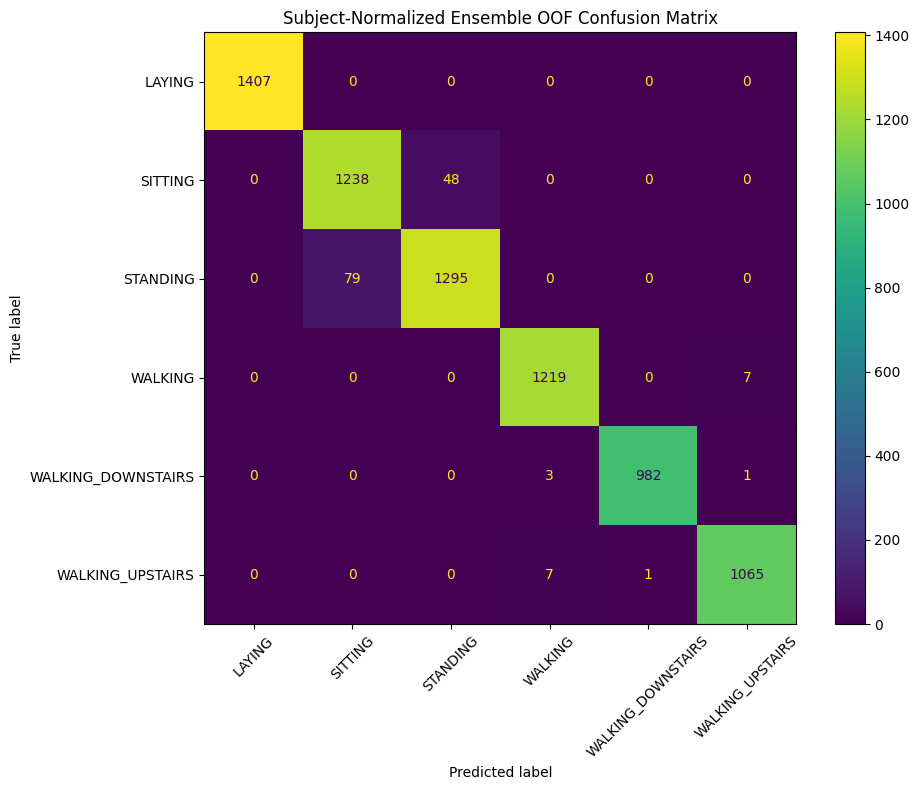

In [12]:
final_oof_metrics = calculate_metrics(
    y,
    final_oof_predictions,
)

print(json.dumps(final_oof_metrics, indent=2))

report_text = classification_report(
    y,
    final_oof_predictions,
    target_names=CLASS_NAMES,
    digits=5,
    zero_division=0,
)

print(report_text)

with open(
    OUTPUT_DIR / "final_oof_classification_report.txt",
    "w",
) as file:
    file.write(report_text)

pd.DataFrame([final_oof_metrics]).to_csv(
    OUTPUT_DIR / "final_oof_metrics.csv",
    index=False,
)

matrix = confusion_matrix(y, final_oof_predictions)

display_object = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=CLASS_NAMES,
)

fig, ax = plt.subplots(figsize=(10, 8))
display_object.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d",
)
plt.title("Subject-Normalized Ensemble OOF Confusion Matrix")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "final_oof_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 13. Train all final models on the complete labelled dataset

In [13]:
full_training_start = time.time()
full_test_probabilities = {}

# Full centered LDA
full_centered_lda = make_lda()
full_centered_lda.fit(X_centered, y)
full_test_probabilities["centered_lda"] = align_probabilities(
    full_centered_lda.predict_proba(X_test_centered),
    full_centered_lda.classes_,
    NUMBER_OF_CLASSES,
)

# Full rank LDA
full_rank_lda = make_lda()
full_rank_lda.fit(X_rank, y)
full_test_probabilities["rank_lda"] = align_probabilities(
    full_rank_lda.predict_proba(X_test_rank),
    full_rank_lda.classes_,
    NUMBER_OF_CLASSES,
)

# Full z-score SVM
full_zscore_svm = make_svm(random_state=SEED)
full_zscore_svm.fit(X_zscore, y)
full_test_probabilities["zscore_svm"] = align_probabilities(
    full_zscore_svm.predict_proba(X_test_zscore),
    full_zscore_svm.classes_,
    NUMBER_OF_CLASSES,
)

# Full hierarchical models
full_group_model = make_lda()
full_group_model.fit(X_zscore, y_group)

full_dynamic_indices = np.flatnonzero(
    np.isin(y, DYNAMIC_CLASS_IDS)
)
full_static_indices = np.flatnonzero(
    np.isin(y, STATIC_CLASS_IDS)
)

full_dynamic_model = make_lda()
full_dynamic_model.fit(
    X_rank[full_dynamic_indices],
    y[full_dynamic_indices],
)

full_static_model = make_lda()
full_static_model.fit(
    X_zscore[full_static_indices],
    y[full_static_indices],
)

full_test_probabilities["hierarchical_lda"] = (
    predict_hierarchical_probabilities(
        full_group_model,
        full_dynamic_model,
        full_static_model,
        X_test_zscore,
        X_test_rank,
        X_test_zscore,
    )
)

# Full SITTING vs STANDING specialist
full_sit_stand_indices = np.flatnonzero(
    np.isin(y, [SITTING_ID, STANDING_ID])
)

full_sit_stand_model = make_lda()
full_sit_stand_model.fit(
    X_rank[full_sit_stand_indices],
    y[full_sit_stand_indices],
)

full_test_sit_stand_specialist = (
    align_sit_stand_probabilities(
        full_sit_stand_model.predict_proba(X_test_rank),
        full_sit_stand_model.classes_,
    )
)

full_training_seconds = time.time() - full_training_start
print(
    f"Full-data models completed in "
    f"{full_training_seconds:.1f} seconds."
)


Full-data models completed in 19.2 seconds.


## 14. Produce full, CV-bagged, and hybrid test probabilities

In [14]:
def finalize_test_probabilities(
    probability_dictionary,
    specialist_probability,
):
    blended = weighted_probability_blend(
        probability_dictionary,
        BEST_WEIGHTS,
    )

    blended = apply_sit_stand_specialist(
        blended,
        specialist_probability,
        BEST_SPECIALIST_ALPHA,
    )

    blended = blended * CLASS_FACTORS
    blended = blended / (
        blended.sum(axis=1, keepdims=True) + 1e-12
    )

    return blended


full_final_test_probabilities = finalize_test_probabilities(
    full_test_probabilities,
    full_test_sit_stand_specialist,
)

cv_bagged_final_test_probabilities = finalize_test_probabilities(
    cv_test_probabilities,
    cv_test_sit_stand_specialist,
)

hybrid_final_test_probabilities = (
    FULL_MODEL_WEIGHT * full_final_test_probabilities
    + CV_BAG_WEIGHT * cv_bagged_final_test_probabilities
)

hybrid_final_test_probabilities = (
    hybrid_final_test_probabilities
    / hybrid_final_test_probabilities.sum(
        axis=1,
        keepdims=True,
    )
)

full_prediction_ids = np.argmax(
    full_final_test_probabilities,
    axis=1,
)

cv_bagged_prediction_ids = np.argmax(
    cv_bagged_final_test_probabilities,
    axis=1,
)

hybrid_prediction_ids = np.argmax(
    hybrid_final_test_probabilities,
    axis=1,
)

print("Prediction count:", len(hybrid_prediction_ids))
print("Full vs CV-bagged disagreements:", np.sum(
    full_prediction_ids != cv_bagged_prediction_ids
))
print("Full vs hybrid disagreements:", np.sum(
    full_prediction_ids != hybrid_prediction_ids
))


Prediction count: 2947
Full vs CV-bagged disagreements: 12
Full vs hybrid disagreements: 5


## 15. Create the primary and alternative Kaggle submissions

In [15]:
def create_submission(prediction_ids, output_path):
    prediction_labels = label_encoder.inverse_transform(
        prediction_ids
    )

    if sample_submission_df is not None:
        submission = sample_submission_df.copy()

        if len(submission) != len(prediction_labels):
            raise ValueError(
                "Sample submission row count does not match predictions."
            )

        target_candidates = [
            column for column in submission.columns
            if column.lower() not in {
                "id",
                "index",
                "sample_id",
            }
        ]

        if len(target_candidates) != 1:
            raise ValueError(
                "Could not identify exactly one target column in "
                f"the sample submission: {submission.columns.tolist()}"
            )

        submission[target_candidates[0]] = prediction_labels

    else:
        if TEST_ID_COLUMN is not None:
            submission_ids = test_df[TEST_ID_COLUMN].to_numpy()
        else:
            submission_ids = np.arange(len(test_df))

        submission = pd.DataFrame({
            "id": submission_ids,
            TARGET_COLUMN: prediction_labels,
        })

    submission.to_csv(output_path, index=False)
    return submission


PRIMARY_SUBMISSION_PATH = (
    OUTPUT_DIR
    / "submission_5_subject_normalized_hybrid.csv"
)

FULL_SUBMISSION_PATH = (
    OUTPUT_DIR
    / "submission_5_subject_normalized_full.csv"
)

CV_BAGGED_SUBMISSION_PATH = (
    OUTPUT_DIR
    / "submission_5_subject_normalized_cvbagged.csv"
)

primary_submission = create_submission(
    hybrid_prediction_ids,
    PRIMARY_SUBMISSION_PATH,
)

full_submission = create_submission(
    full_prediction_ids,
    FULL_SUBMISSION_PATH,
)

cv_bagged_submission = create_submission(
    cv_bagged_prediction_ids,
    CV_BAGGED_SUBMISSION_PATH,
)

print("Primary submission:", PRIMARY_SUBMISSION_PATH)
print("Full-model alternative:", FULL_SUBMISSION_PATH)
print("CV-bagged alternative:", CV_BAGGED_SUBMISSION_PATH)
print("Submission shape:", primary_submission.shape)
print("Missing values:")
print(primary_submission.isnull().sum())

display(primary_submission.head())
display(primary_submission.tail())


Primary submission: /kaggle/working/submission5_subject_ensemble_outputs/submission_5_subject_normalized_hybrid.csv
Full-model alternative: /kaggle/working/submission5_subject_ensemble_outputs/submission_5_subject_normalized_full.csv
CV-bagged alternative: /kaggle/working/submission5_subject_ensemble_outputs/submission_5_subject_normalized_cvbagged.csv
Submission shape: (2947, 2)
Missing values:
id          0
Activity    0
dtype: int64


,id,Activity
0,1,STANDING
1,2,STANDING
2,3,STANDING
3,4,STANDING
4,5,STANDING


,id,Activity
2942,2943,WALKING_UPSTAIRS
2943,2944,WALKING_UPSTAIRS
2944,2945,WALKING_UPSTAIRS
2945,2946,WALKING_UPSTAIRS
2946,2947,WALKING_UPSTAIRS


## 16. Save probabilities and run summary

In [16]:
np.save(
    OUTPUT_DIR / "full_test_probabilities.npy",
    full_final_test_probabilities,
)

np.save(
    OUTPUT_DIR / "cv_bagged_test_probabilities.npy",
    cv_bagged_final_test_probabilities,
)

np.save(
    OUTPUT_DIR / "hybrid_test_probabilities.npy",
    hybrid_final_test_probabilities,
)

np.save(
    OUTPUT_DIR / "final_oof_probabilities.npy",
    final_oof_probabilities,
)

run_summary = {
    "submission": "Submission 5 - Subject-Normalized Hierarchical Ensemble",
    "features": len(feature_columns),
    "classes": CLASS_NAMES.tolist(),
    "folds": N_FOLDS,
    "validation": "GroupKFold by subject",
    "subject_representations": [
        "centered",
        "z-score",
        "within-subject rank",
    ],
    "models": MODEL_NAMES,
    "best_weights": BEST_WEIGHTS,
    "sit_stand_specialist_alpha": BEST_SPECIALIST_ALPHA,
    "class_factors": {
        class_name: float(factor)
        for class_name, factor in zip(
            CLASS_NAMES,
            CLASS_FACTORS,
        )
    },
    "oof_metrics": {
        key: float(value)
        for key, value in final_oof_metrics.items()
    },
    "full_model_weight": FULL_MODEL_WEIGHT,
    "cv_bag_weight": CV_BAG_WEIGHT,
    "cross_validation_seconds": training_seconds,
    "full_training_seconds": full_training_seconds,
    "primary_submission_path": str(PRIMARY_SUBMISSION_PATH),
    "full_submission_path": str(FULL_SUBMISSION_PATH),
    "cv_bagged_submission_path": str(CV_BAGGED_SUBMISSION_PATH),
    "hidden_test_labels_used": False,
}

with open(
    OUTPUT_DIR / "submission_5_summary.json",
    "w",
) as file:
    json.dump(run_summary, file, indent=2)

print(json.dumps(run_summary, indent=2))


{
  "submission": "Submission 5 - Subject-Normalized Hierarchical Ensemble",
  "features": 561,
  "classes": [
    "LAYING",
    "SITTING",
    "STANDING",
    "WALKING",
    "WALKING_DOWNSTAIRS",
    "WALKING_UPSTAIRS"
  ],
  "folds": 5,
  "validation": "GroupKFold by subject",
  "subject_representations": [
    "centered",
    "z-score",
    "within-subject rank"
  ],
  "models": [
    "centered_lda",
    "rank_lda",
    "zscore_svm",
    "hierarchical_lda"
  ],
  "best_weights": {
    "centered_lda": 0.3,
    "rank_lda": 0.1,
    "zscore_svm": 0.2,
    "hierarchical_lda": 0.4
  },
  "sit_stand_specialist_alpha": 0.12,
  "class_factors": {
    "LAYING": 1.0,
    "SITTING": 1.12,
    "STANDING": 1.02,
    "WALKING": 0.9400000000000001,
    "WALKING_DOWNSTAIRS": 1.0,
    "WALKING_UPSTAIRS": 0.93
  },
  "oof_metrics": {
    "accuracy": 0.9801414581066377,
    "macro_precision": 0.9812774308843454,
    "macro_recall": 0.9813260747680578,
    "macro_f1": 0.9812579459884967,
    "weighted_

## 17. List generated files

In [17]:
generated_files = sorted(
    path for path in OUTPUT_DIR.rglob("*")
    if path.is_file()
)

for path in generated_files:
    print(path)


/kaggle/working/submission5_subject_ensemble_outputs/base_model_oof_results.csv
/kaggle/working/submission5_subject_ensemble_outputs/cv_bagged_test_probabilities.npy
/kaggle/working/submission5_subject_ensemble_outputs/ensemble_weight_search.csv
/kaggle/working/submission5_subject_ensemble_outputs/final_oof_classification_report.txt
/kaggle/working/submission5_subject_ensemble_outputs/final_oof_confusion_matrix.png
/kaggle/working/submission5_subject_ensemble_outputs/final_oof_metrics.csv
/kaggle/working/submission5_subject_ensemble_outputs/final_oof_probabilities.npy
/kaggle/working/submission5_subject_ensemble_outputs/fold_results.csv
/kaggle/working/submission5_subject_ensemble_outputs/full_test_probabilities.npy
/kaggle/working/submission5_subject_ensemble_outputs/hybrid_test_probabilities.npy
/kaggle/working/submission5_subject_ensemble_outputs/sit_stand_specialist_search.csv
/kaggle/working/submission5_subject_ensemble_outputs/submission_5_subject_normalized_cvbagged.csv
/kaggle/